Shape do dataset: (36356, 2)

Colunas: ['target', 'inputs']

Distribuição do target:
target
1    20126
0    16230
Name: count, dtype: int64

Proporção:
target
1    0.553581
0    0.446419
Name: proportion, dtype: float64
Parseando inputs...
Linhas parseadas com sucesso: 36356 de 36356
Extraindo features...
Processadas 5000 linhas...
Processadas 10000 linhas...
Processadas 15000 linhas...
Processadas 20000 linhas...
Processadas 25000 linhas...
Processadas 30000 linhas...
Processadas 35000 linhas...

Features extraídas: (35094, 26)
Perdemos 1262 linhas com problemas
Colunas com valores ausentes:
hold_mean            1430
hold_std             1430
hold_min             1430
hold_max             1430
hold_median          1430
hold_q25             1430
hold_q75             1430
hold_cv              1430
flight_mean           311
flight_std            311
flight_min            311
flight_max            311
flight_median         311
flight_cv             311
press_press_mean      511
press_pres

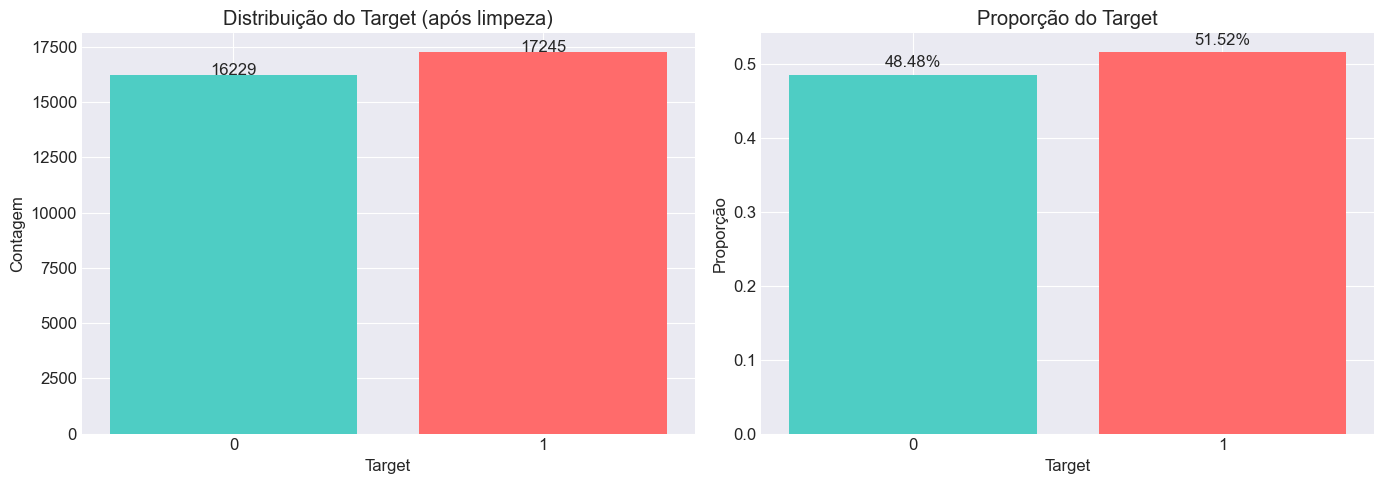

Classe 0: 48.48%
Classe 1: 51.52%


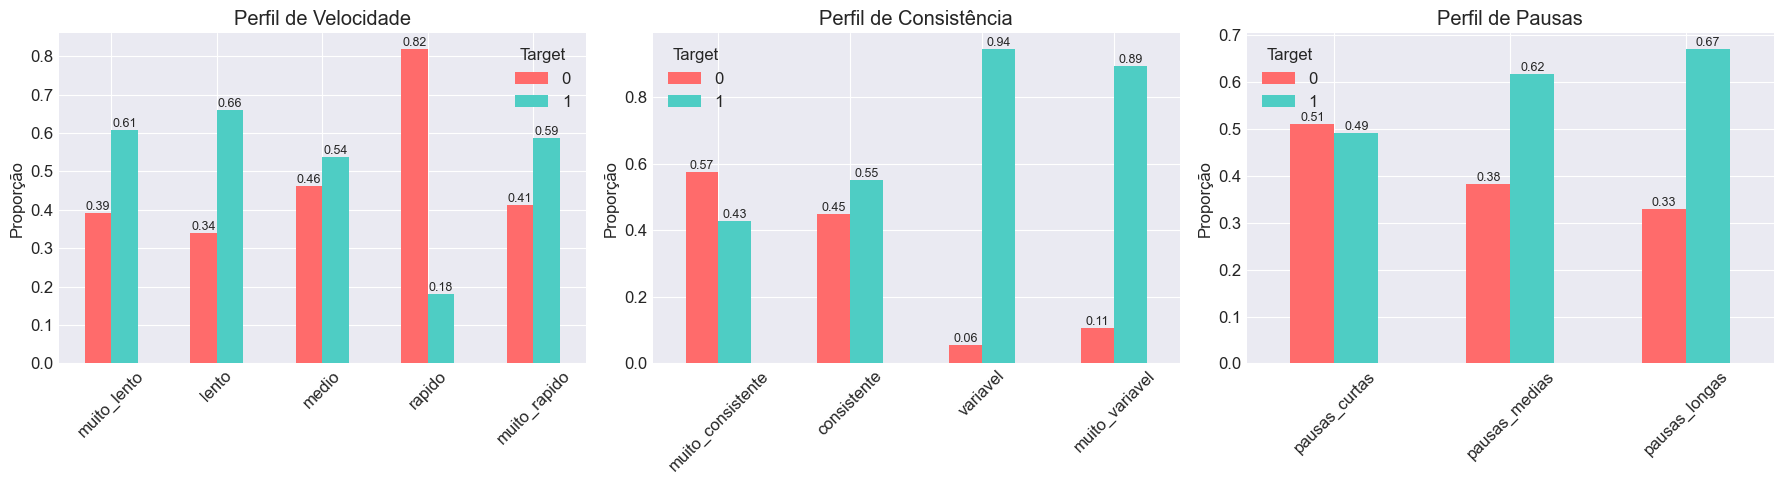

Shape para análise numérica: (33277, 13)


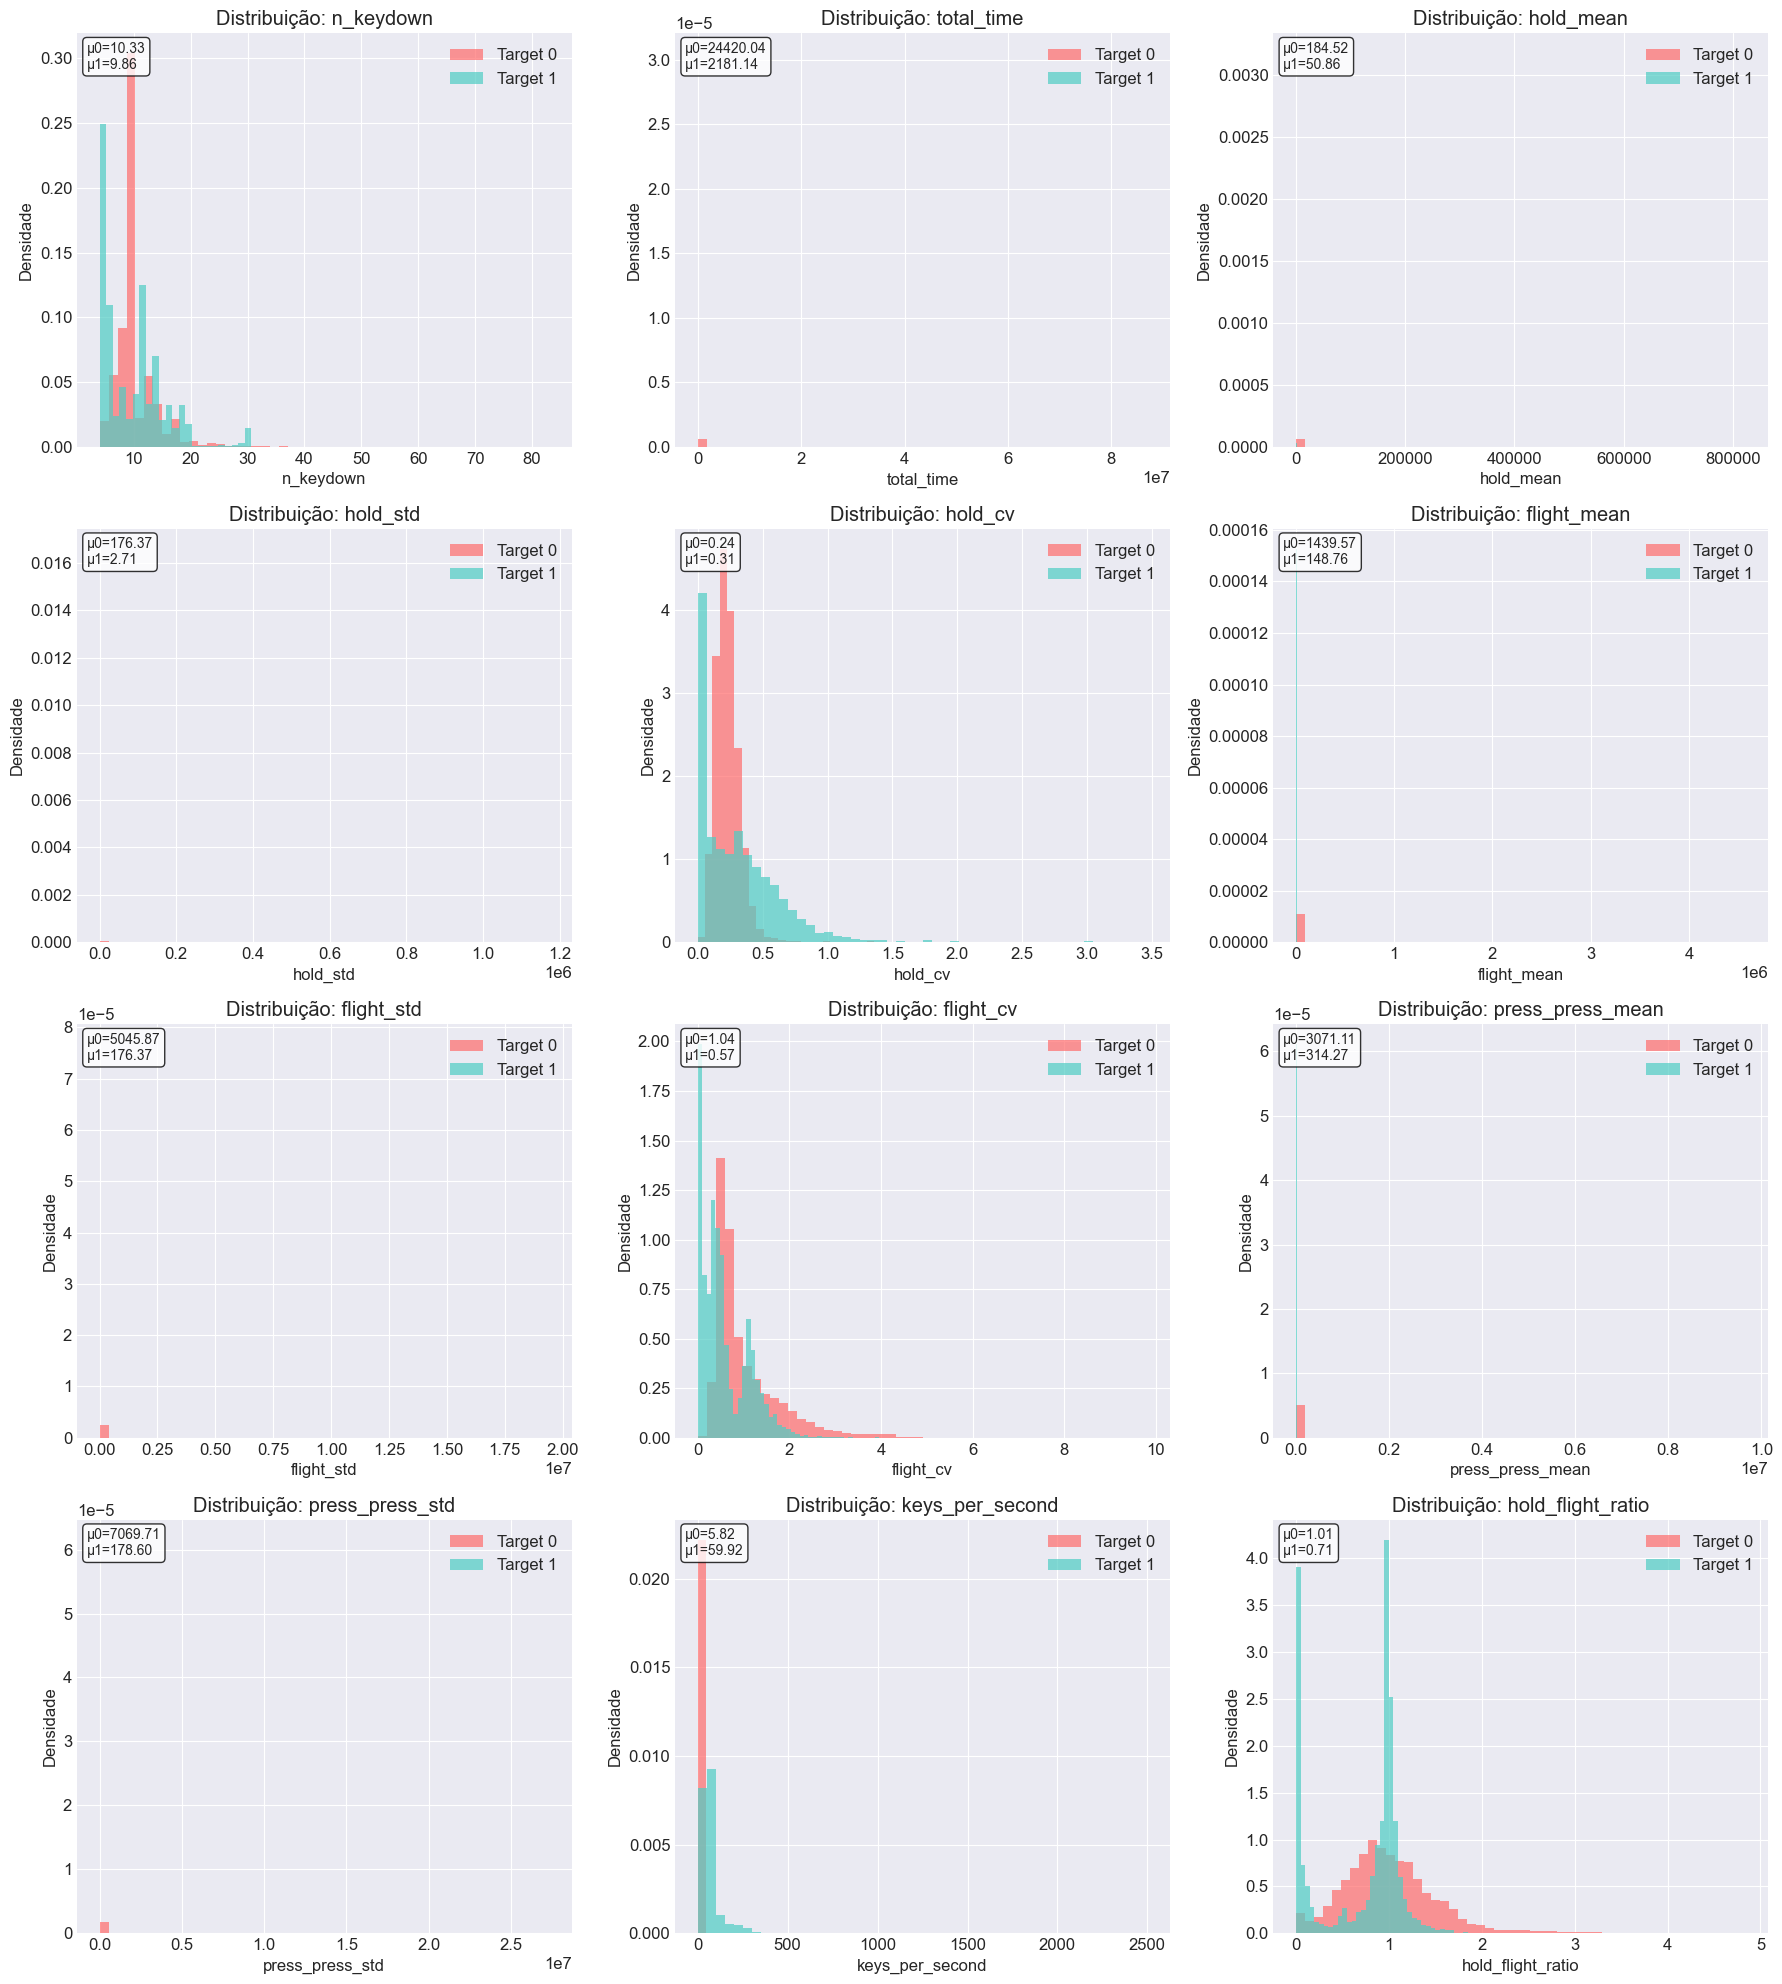

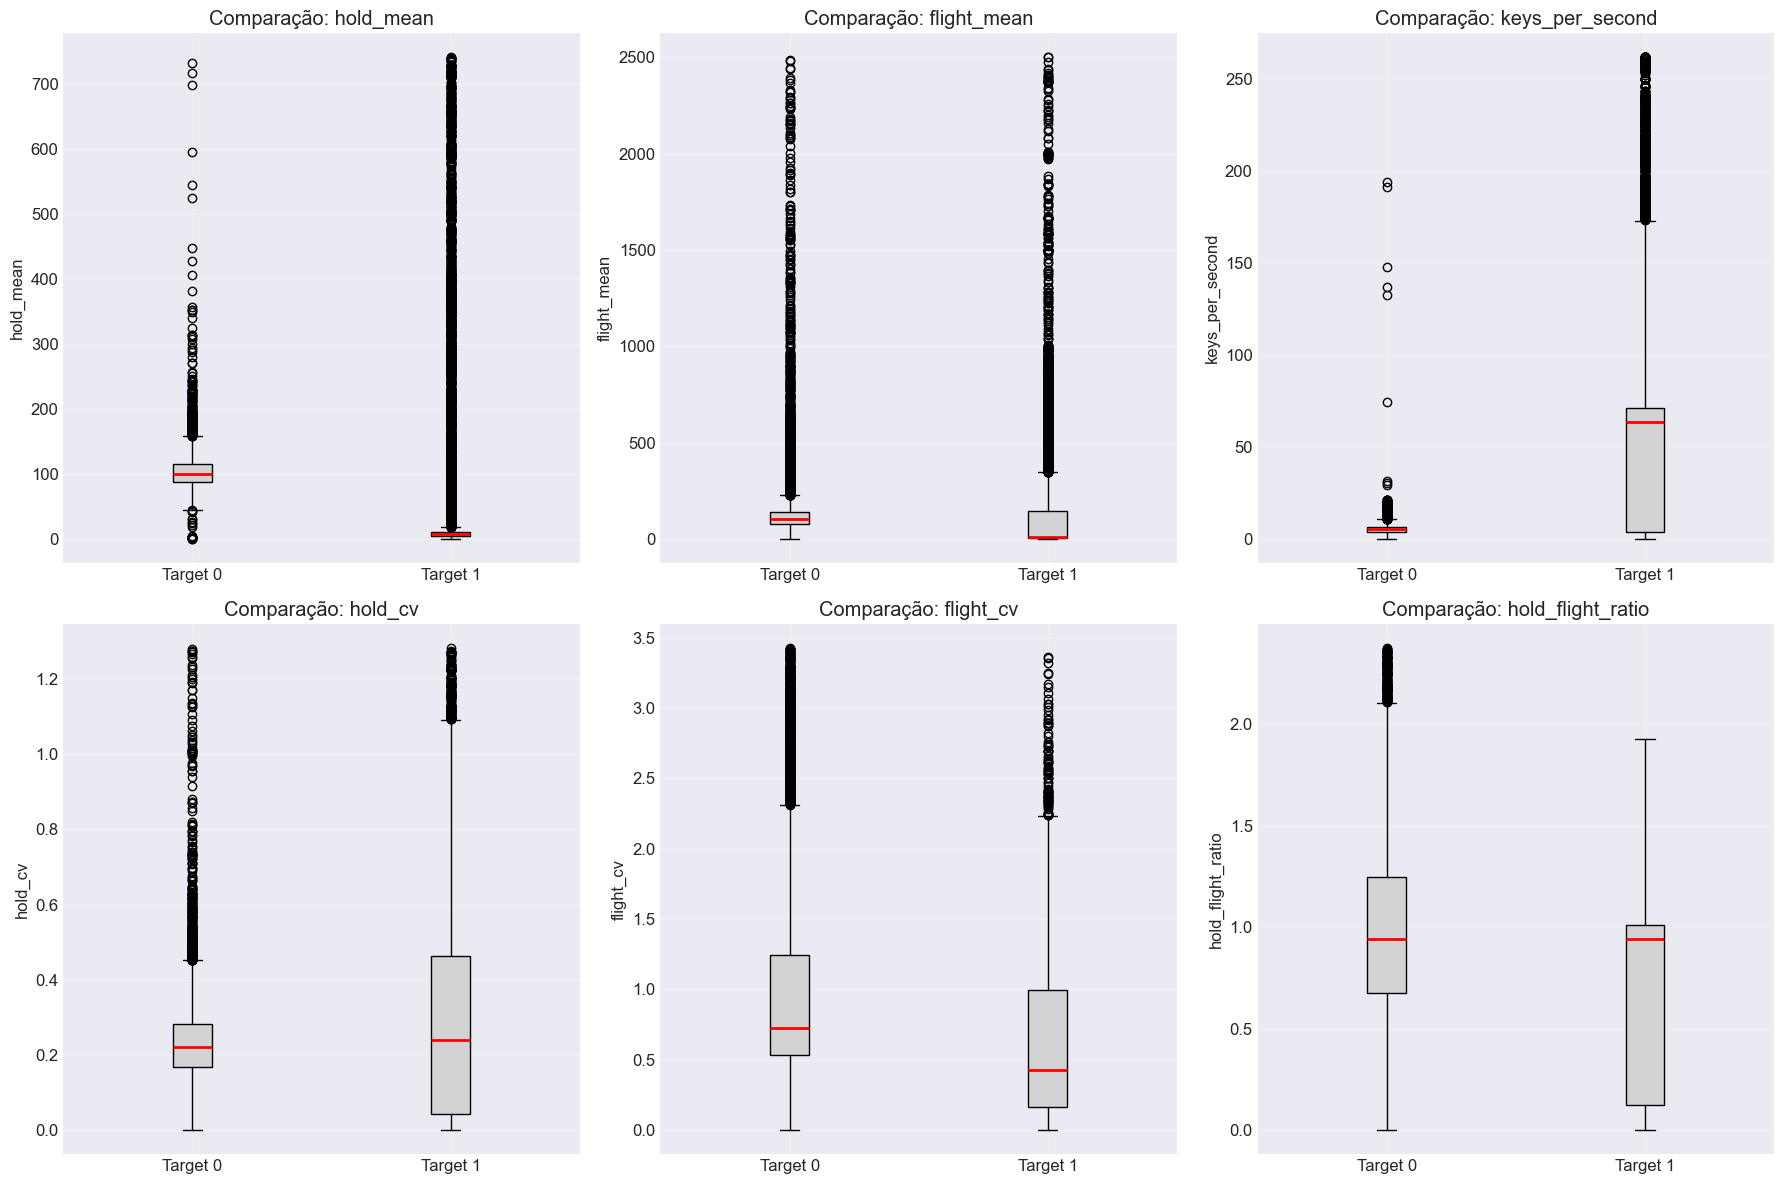

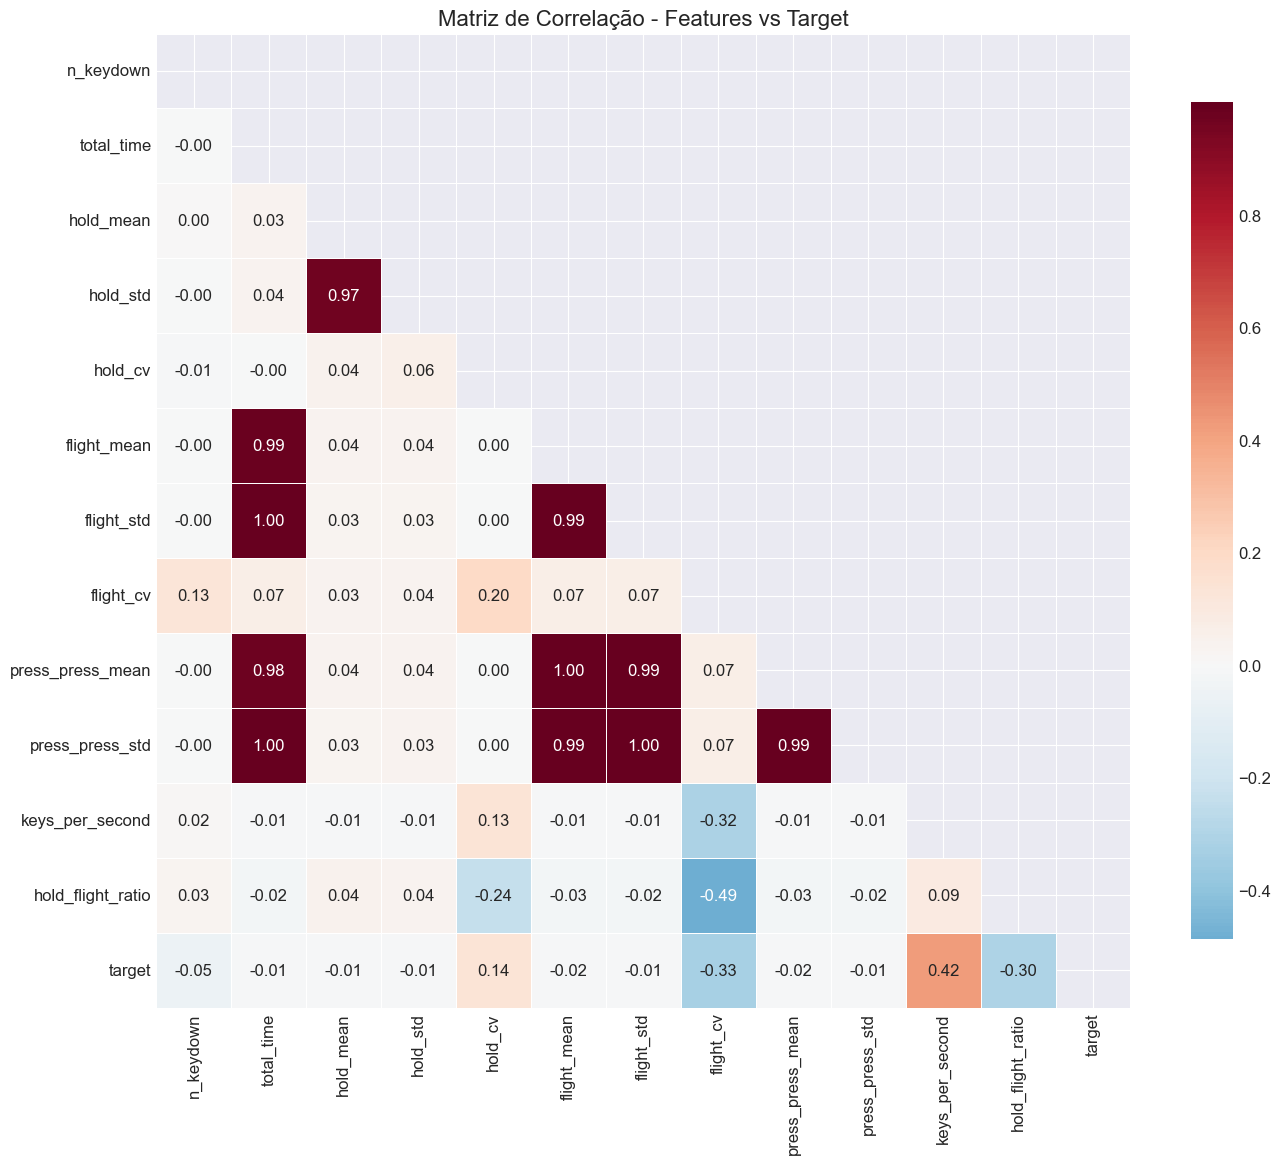


Correlações com Target (top 10):
keys_per_second     0.423882
hold_cv             0.137194
hold_std           -0.010502
hold_mean          -0.013584
flight_std         -0.014420
press_press_std    -0.014616
total_time         -0.014874
flight_mean        -0.015333
press_press_mean   -0.015987
n_keydown          -0.052866
Name: target, dtype: float64

TESTES DE HIPÓTESES

H1: Velocidade de digitação
  Target 0 - média: 5.82 teclas/s
  Target 1 - média: 59.26 teclas/s
  Teste Mann-Whitney: p-value = 0.000000
  Conclusão: ✅ Diferença significativa

H2: Tempo de pressão (hold time)
  Target 0 - média: 184.52 ms
  Target 1 - média: 50.31 ms
  Teste Mann-Whitney: p-value = 0.000000
  Conclusão: ✅ Diferença significativa

H3: Consistência (coeficiente de variação)
  Target 0 - média CV: 0.242
  Target 1 - média CV: 0.314
  Teste Mann-Whitney: p-value = 0.000081
  Conclusão: ✅ Diferença significativa

RESUMO DA ANÁLISE EXPLORATÓRIA

📊 **Distribuição do Target**:
  - Classe 0: 48.5%
  - Classe

In [ ]:
# # Análise Exploratória - Desafio de Classificação de Digitação
# 
# **Objetivo**: Entender os padrões de digitação e como eles se relacionam com o target (0 ou 1)
# 
# **Perguntas**:
# Pergunta central: "Os padrões de digitação de uma pessoa (velocidade, ritmo, pausas e consistência) podem prever se ela pertence ao grupo 0 ou 1?"
# Hipóteses a testar:
# - Pessoas que digitam mais rápido tendem mais ao grupo 1?
# - Pessoas que seguram as teclas por mais tempo tendem mais ao grupo 0?
# - Digitações mais consistentes (baixa variabilidade) são características de algum grupo?
# - Sessões mais longas (mais teclas) favorecem algum grupo?

# 1. Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import defaultdict
import ast
import warnings
warnings.filterwarnings('ignore')

# Configuração de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


# ## 1. Carregamento dos dados


# Carregar dados de treino
df_train = pd.read_csv(r'C:\Users\DANIEL.SSANTANA\OneDrive - sp.senac.br\Área de Trabalho\keyboard_project\data\train.csv')

print(f"Shape do dataset: {df_train.shape}")
print(f"\nColunas: {df_train.columns.tolist()}")
print(f"\nDistribuição do target:")
print(df_train['target'].value_counts())
print(f"\nProporção:\n{df_train['target'].value_counts(normalize=True)}")


# ## 2. Função de parseamento robusta


def safe_parse_inputs(inputs_str):
    """
    Convertr string de inputs para dicionário
    """
    try:
        # Substituir aspas simples por duplas para o literal_eval
        fixed_str = inputs_str.replace("'", '"')
        return json.loads(fixed_str)
    except:
        try:
            return ast.literal_eval(inputs_str)
        except:
            return None

def extract_features_safe(row):
    """
    Extrair features de UMA linha com tratamento de erros
    """
    try:
        data = row['inputs_parsed']
        if data is None or 'keyboard' not in data:
            return None
        
        keyboard_data = data['keyboard']
        
        # Verificar se keydown e keyup existem
        keydown = keyboard_data.get('keydown', [])
        keyup = keyboard_data.get('keyup', [])
        
        # Se não houver eventos, retornar None
        if len(keydown) == 0 or len(keyup) == 0:
            return None
        
        feat = {'target': row['target']}
        
        # Features básicas
        feat['length'] = data.get('length', len(keydown))
        feat['n_keydown'] = len(keydown)
        feat['n_keyup'] = len(keyup)
        feat['n_unique_codes'] = len(set([e['code'] for e in keydown]))
        
        # Tempos totais
        all_ticks = [e['tick'] for e in keydown] + [e['tick'] for e in keyup]
        feat['total_time'] = max(all_ticks) - min(all_ticks)
        feat['first_tick'] = min([e['tick'] for e in keydown])
        
        # Calcular hold times (pareamento keydown-keyup)
        hold_times = []
        
        # Criar dicionário de keydowns agrupados por código
        keydown_dict = defaultdict(list)
        for event in keydown:
            keydown_dict[event['code']].append(event['tick'])
        
        # Para cada keyup, encontrar o keydown correspondente mais antigo
        for event in sorted(keyup, key=lambda x: x['tick']):
            code = event['code']
            if code in keydown_dict and keydown_dict[code]:
                # Pegar o keydown mais antigo para este código
                press_time = keydown_dict[code].pop(0)
                hold_time = event['tick'] - press_time
                if hold_time >= 0:  # garantir tempo não negativo
                    hold_times.append(hold_time)
        
        # Estatísticas de hold times
        if len(hold_times) > 1:
            feat['hold_mean'] = np.mean(hold_times)
            feat['hold_std'] = np.std(hold_times)
            feat['hold_min'] = np.min(hold_times)
            feat['hold_max'] = np.max(hold_times)
            feat['hold_median'] = np.median(hold_times)
            feat['hold_q25'] = np.percentile(hold_times, 25)
            feat['hold_q75'] = np.percentile(hold_times, 75)
            feat['hold_cv'] = feat['hold_std'] / feat['hold_mean'] if feat['hold_mean'] > 0 else 0 # Coeficiente de variação: O CV diz quão consistentes são os tempos de digitação de uma pessoa, independentemente da velocidade dela.
        else:
            # Se não há hold times suficientes, preencher com NaN
            feat['hold_mean'] = np.nan
            feat['hold_std'] = np.nan
            feat['hold_min'] = np.nan
            feat['hold_max'] = np.nan
            feat['hold_median'] = np.nan
            feat['hold_q25'] = np.nan
            feat['hold_q75'] = np.nan
            feat['hold_cv'] = np.nan
        
        # Calcular flight times (intervalos entre eventos consecutivos)
        all_events = []
        for e in keydown:
            all_events.append(('down', e['code'], e['tick']))
        for e in keyup:
            all_events.append(('up', e['code'], e['tick']))
        
        all_events.sort(key=lambda x: x[2])
        
        flight_times = []
        for i in range(1, len(all_events)):
            diff = all_events[i][2] - all_events[i-1][2]
            if diff > 0:  # garantir diferença positiva
                flight_times.append(diff)
        
        if len(flight_times) > 1:
            feat['flight_mean'] = np.mean(flight_times)
            feat['flight_std'] = np.std(flight_times)
            feat['flight_min'] = np.min(flight_times)
            feat['flight_max'] = np.max(flight_times)
            feat['flight_median'] = np.median(flight_times)
            feat['flight_cv'] = feat['flight_std'] / feat['flight_mean'] if feat['flight_mean'] > 0 else 0
        else:
            feat['flight_mean'] = np.nan
            feat['flight_std'] = np.nan
            feat['flight_min'] = np.nan
            feat['flight_max'] = np.nan
            feat['flight_median'] = np.nan
            feat['flight_cv'] = np.nan
        
        # Calcular press-press intervals
        keydown_times = sorted([e['tick'] for e in keydown])
        press_press = []
        for i in range(1, len(keydown_times)):
            diff = keydown_times[i] - keydown_times[i-1]
            if diff > 0:
                press_press.append(diff)
        
        if len(press_press) > 1:
            feat['press_press_mean'] = np.mean(press_press)
            feat['press_press_std'] = np.std(press_press)
            feat['press_press_cv'] = feat['press_press_std'] / feat['press_press_mean'] if feat['press_press_mean'] > 0 else 0
        else:
            feat['press_press_mean'] = np.nan
            feat['press_press_std'] = np.nan
            feat['press_press_cv'] = np.nan
        
        # Feature: velocidade média (teclas por segundo)
        if feat['total_time'] > 0:
            feat['keys_per_second'] = feat['n_keydown'] / (feat['total_time'] / 1000)
        else:
            feat['keys_per_second'] = np.nan
        
        # Feature: proporção hold/flight
        if not np.isnan(feat['flight_mean']) and feat['flight_mean'] > 0 and not np.isnan(feat['hold_mean']):
            feat['hold_flight_ratio'] = feat['hold_mean'] / feat['flight_mean']
        else:
            feat['hold_flight_ratio'] = np.nan
        
        return feat
        
    except Exception as e:
        # Silenciosamente ignorar erros
        return None


# ## 3. Processamento dos dados (linha a linha com segurança)


print("Parseando inputs...")
df_train['inputs_parsed'] = df_train['inputs'].apply(safe_parse_inputs)

# Verificar quantos foram parseados com sucesso
valid_parsed = df_train['inputs_parsed'].notna().sum()
print(f"Linhas parseadas com sucesso: {valid_parsed} de {len(df_train)}")

# Extrair features
print("Extraindo features...")
features_list = []

for idx, row in df_train.iterrows():
    if idx % 5000 == 0 and idx > 0:
        print(f"Processadas {idx} linhas...")
    
    feat = extract_features_safe(row)
    if feat is not None:
        features_list.append(feat)

df_features = pd.DataFrame(features_list)

print(f"\nFeatures extraídas: {df_features.shape}")
print(f"Perdemos {len(df_train) - len(df_features)} linhas com problemas")


# ## 4. Limpeza de dados (remover NaN)


# Verificar colunas com muitos NaN
nan_counts = df_features.isna().sum()
print("Colunas com valores ausentes:")
print(nan_counts[nan_counts > 0])

# Remover linhas com NaN nas colunas essenciais
essential_cols = ['hold_mean', 'flight_mean', 'keys_per_second']
df_clean = df_features.dropna(subset=essential_cols).copy()

print(f"\nShape após remoção de NaN: {df_clean.shape}")


# ## 5. Análise de balanceamento


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contagem
ax = axes[0]
counts = df_clean['target'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#ff6b6b', '#4ecdc4'])
ax.set_xlabel('Target')
ax.set_ylabel('Contagem')
ax.set_title('Distribuição do Target (após limpeza)')
ax.set_xticks([0, 1])
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
            str(count), ha='center', fontsize=12)

# Proporção
ax = axes[1]
props = df_clean['target'].value_counts(normalize=True)
bars = ax.bar(props.index, props.values, color=['#ff6b6b', '#4ecdc4'])
ax.set_xlabel('Target')
ax.set_ylabel('Proporção')
ax.set_title('Proporção do Target')
ax.set_xticks([0, 1])
for bar, prop in zip(bars, props.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{prop:.2%}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Classe 0: {props[0]:.2%}")
print(f"Classe 1: {props[1]:.2%}")


# ## 6. Análise de Perfis de Digitação

# Criar perfis categóricos baseados nos dados reais

def create_profiles(row):
    profiles = {}
    
    # Perfil de velocidade
    kps = row['keys_per_second']
    if kps > 5:
        profiles['speed'] = 'muito_rapido'
    elif kps > 3:
        profiles['speed'] = 'rapido'
    elif kps > 2:
        profiles['speed'] = 'medio'
    elif kps > 1:
        profiles['speed'] = 'lento'
    else:
        profiles['speed'] = 'muito_lento'
    
    # Perfil de consistência
    cv = row['hold_cv']
    if cv < 0.3:
        profiles['consistency'] = 'muito_consistente'
    elif cv < 0.5:
        profiles['consistency'] = 'consistente'
    elif cv < 0.8:
        profiles['consistency'] = 'variavel'
    else:
        profiles['consistency'] = 'muito_variavel'
    
    # Perfil de pausas
    flight = row['flight_mean']
    if flight < 200:
        profiles['pauses'] = 'pausas_curtas'
    elif flight < 400:
        profiles['pauses'] = 'pausas_medias'
    else:
        profiles['pauses'] = 'pausas_longas'
    
    return pd.Series(profiles)

# Aplicar perfis
profiles_df = df_clean.apply(create_profiles, axis=1)
df_with_profiles = pd.concat([df_clean, profiles_df], axis=1)


# ### Visualização dos Perfis


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

profiles_to_plot = ['speed', 'consistency', 'pauses']
profile_titles = ['Perfil de Velocidade', 'Perfil de Consistência', 'Perfil de Pausas']

for ax, profile, title in zip(axes, profiles_to_plot, profile_titles):
    # Calcular proporções
    ct = pd.crosstab(df_with_profiles[profile], df_with_profiles['target'], normalize='index')
    
    # Ordenar categorias
    if profile == 'speed':
        ct = ct.reindex(['muito_lento', 'lento', 'medio', 'rapido', 'muito_rapido'])
    elif profile == 'consistency':
        ct = ct.reindex(['muito_consistente', 'consistente', 'variavel', 'muito_variavel'])
    else:
        ct = ct.reindex(['pausas_curtas', 'pausas_medias', 'pausas_longas'])
    
    ct.plot(kind='bar', ax=ax, color=['#ff6b6b', '#4ecdc4'])
    ax.set_xlabel('')
    ax.set_ylabel('Proporção')
    ax.set_title(title)
    ax.legend(title='Target', labels=['0', '1'])
    ax.tick_params(axis='x', rotation=45)
    
    # Adicionar valores
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.tight_layout()
plt.show()


# ## 7. Análise de Features Numéricas (com tratamento de infinitos)


# Selecionar features numéricas principais
numeric_features = ['n_keydown', 'total_time', 'hold_mean', 'hold_std', 'hold_cv',
                   'flight_mean', 'flight_std', 'flight_cv', 'press_press_mean',
                   'press_press_std', 'keys_per_second', 'hold_flight_ratio']

# Verificar se existem no dataframe
numeric_features = [f for f in numeric_features if f in df_clean.columns]

# Remover valores infinitos
df_clean_num = df_clean[numeric_features + ['target']].replace([np.inf, -np.inf], np.nan).dropna()

print(f"Shape para análise numérica: {df_clean_num.shape}")

# Distribuições por target
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    if i >= len(axes):
        break
    
    ax = axes[i]
    
    data_0 = df_clean_num[df_clean_num['target'] == 0][feature]
    data_1 = df_clean_num[df_clean_num['target'] == 1][feature]
    
    # Verificar se há dados suficientes
    if len(data_0) > 0 and len(data_1) > 0:
        ax.hist(data_0, bins=50, alpha=0.7, label='Target 0', color='#ff6b6b', density=True)
        ax.hist(data_1, bins=50, alpha=0.7, label='Target 1', color='#4ecdc4', density=True)
        
        ax.set_xlabel(feature)
        ax.set_ylabel('Densidade')
        ax.set_title(f'Distribuição: {feature}')
        ax.legend()
        
        # Estatísticas
        ax.text(0.02, 0.98, f'μ0={data_0.mean():.2f}\nμ1={data_1.mean():.2f}', 
                transform=ax.transAxes, va='top', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        ax.text(0.5, 0.5, 'Dados insuficientes', ha='center', va='center')
        ax.set_title(feature)

# Remover subplots vazios
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# ## 8. Boxplots Comparativos (com tratamento de outliers)


fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

box_features = ['hold_mean', 'flight_mean', 'keys_per_second', 
                'hold_cv', 'flight_cv', 'hold_flight_ratio']
box_features = [f for f in box_features if f in df_clean.columns]

for i, feature in enumerate(box_features):
    ax = axes[i]
    
    # Limitar outliers para visualização (percentil 99)
    q99 = df_clean[feature].quantile(0.99)
    df_box = df_clean[df_clean[feature] <= q99][[feature, 'target']].dropna()
    
    if len(df_box) > 0:
        data_0 = df_box[df_box['target'] == 0][feature]
        data_1 = df_box[df_box['target'] == 1][feature]
        
        bp = ax.boxplot([data_0, data_1],
                        labels=['Target 0', 'Target 1'],
                        patch_artist=True,
                        boxprops=dict(facecolor='lightgray'),
                        medianprops=dict(color='red', linewidth=2))
        
        ax.set_ylabel(feature)
        ax.set_title(f'Comparação: {feature}')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Dados insuficientes', ha='center', va='center')
        ax.set_title(feature)

plt.tight_layout()
plt.show()


# ## 9. Matriz de Correlação


# Selecionar features numéricas para correlação
corr_features = numeric_features + ['target']
corr_features = [f for f in corr_features if f in df_clean.columns]

# Calcular correlação
corr_matrix = df_clean[corr_features].corr()

# Plotar heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Features vs Target', fontsize=16)
plt.tight_layout()
plt.show()

# Correlações com target
target_corr = corr_matrix['target'].drop('target').sort_values(ascending=False)
print("\nCorrelações com Target (top 10):")
print(target_corr.head(10))


# ## 10. Testes de Hipóteses Estatísticas


from scipy import stats

print("\n" + "="*60)
print("TESTES DE HIPÓTESES")
print("="*60)

# Hipótese 1: Velocidade (keys_per_second) difere entre grupos
h0_data = df_clean[df_clean['target'] == 0]['keys_per_second'].dropna()
h1_data = df_clean[df_clean['target'] == 1]['keys_per_second'].dropna()

stat, p_value = stats.mannwhitneyu(h0_data, h1_data, alternative='two-sided')
print(f"\nH1: Velocidade de digitação")
print(f"  Target 0 - média: {h0_data.mean():.2f} teclas/s")
print(f"  Target 1 - média: {h1_data.mean():.2f} teclas/s")
print(f"  Teste Mann-Whitney: p-value = {p_value:.6f}")
print(f"  Conclusão: {'✅ Diferença significativa' if p_value < 0.05 else '❌ Sem diferença significativa'}")

# Hipótese 2: Hold time difere entre grupos
h0_data = df_clean[df_clean['target'] == 0]['hold_mean'].dropna()
h1_data = df_clean[df_clean['target'] == 1]['hold_mean'].dropna()

stat, p_value = stats.mannwhitneyu(h0_data, h1_data, alternative='two-sided')
print(f"\nH2: Tempo de pressão (hold time)")
print(f"  Target 0 - média: {h0_data.mean():.2f} ms")
print(f"  Target 1 - média: {h1_data.mean():.2f} ms")
print(f"  Teste Mann-Whitney: p-value = {p_value:.6f}")
print(f"  Conclusão: {'✅ Diferença significativa' if p_value < 0.05 else '❌ Sem diferença significativa'}")

# Hipótese 3: Consistência (CV) difere entre grupos
h0_data = df_clean[df_clean['target'] == 0]['hold_cv'].dropna()
h1_data = df_clean[df_clean['target'] == 1]['hold_cv'].dropna()

stat, p_value = stats.mannwhitneyu(h0_data, h1_data, alternative='two-sided')
print(f"\nH3: Consistência (coeficiente de variação)")
print(f"  Target 0 - média CV: {h0_data.mean():.3f}")
print(f"  Target 1 - média CV: {h1_data.mean():.3f}")
print(f"  Teste Mann-Whitney: p-value = {p_value:.6f}")
print(f"  Conclusão: {'✅ Diferença significativa' if p_value < 0.05 else '❌ Sem diferença significativa'}")


# ## 11. Resumo e Conclusões


print("\n" + "="*60)
print("RESUMO DA ANÁLISE EXPLORATÓRIA")
print("="*60)

print("\n📊 **Distribuição do Target**:")
prop_0 = df_clean['target'].value_counts(normalize=True)[0]
prop_1 = df_clean['target'].value_counts(normalize=True)[1]
print(f"  - Classe 0: {prop_0:.1%}")
print(f"  - Classe 1: {prop_1:.1%}")

print("\n🔍 **Principais Insights:**")

vel_0 = df_clean[df_clean['target'] == 0]['keys_per_second'].mean()
vel_1 = df_clean[df_clean['target'] == 1]['keys_per_second'].mean()
print(f"  - Velocidade média: Classe 0 = {vel_0:.2f} teclas/s | Classe 1 = {vel_1:.2f} teclas/s")

hold_0 = df_clean[df_clean['target'] == 0]['hold_mean'].mean()
hold_1 = df_clean[df_clean['target'] == 1]['hold_mean'].mean()
print(f"  - Hold time médio: Classe 0 = {hold_0:.0f} ms | Classe 1 = {hold_1:.0f} ms")

cv_0 = df_clean[df_clean['target'] == 0]['hold_cv'].mean()
cv_1 = df_clean[df_clean['target'] == 1]['hold_cv'].mean()
print(f"  - Consistência (CV): Classe 0 = {cv_0:.3f} | Classe 1 = {cv_1:.3f}")

print("\n📈 **Features mais correlacionadas com target:**")
top_features = target_corr.head(5)
for feat, corr in top_features.items():
    direction = "positiva" if corr > 0 else "negativa"
    print(f"  - {feat}: {corr:.3f} (correlação {direction})")

# Salvar dados processados para modelagem
df_clean.to_csv(r'C:\Users\DANIEL.SSANTANA\OneDrive - sp.senac.br\Área de Trabalho\keyboard_project\data\features_train.csv', index=False)
print("\n✅ Dados processados salvos em 'features_train.csv'")

print("\n💡 **Recomendações para Modelagem:**")
print("""
1. Features mais promissoras: hold_mean, keys_per_second, flight_mean
2. Perfis categóricos (velocidade, consistência) podem ser bons preditores
3. Considerar criar features de interação (ex: hold_mean × keys_per_second)
4. Validar se há necessidade de balanceamento (dependendo dos resultados acima)
5. Testar modelos que capturem não-linearidades (MOdelo a serem treinados: Regressão logistica, Random Forest, XGBoost)
""")

### INTERPRETAÇÃO DOS RESULTADOS - Análise Exploratória

#### Visão Geral
Os dados revelam um padrão EXTREMAMENTE CLARO de separação entre as classes 0 e 1.:
1. Distribuição do Target (Balanceamento)
- Classe 0: 48.5%
- Classe 1: 51.5%

Interpretação: Dataset praticamente balanceado! não precisaremos utilizar técnicas de balanceamento como SMOTE ou class_weight.

#### -----------------------------------------------------------------------------
2. Velocidade de Digitação
Classe 0: 5.82 teclas/segundo
Classe 1: 59.26 teclas/segundo
Correlação com target: +0.424

Interpretação: O grupo 1 digita 10x mais rápido que o grupo 0.

- Grupo 0 (~6 teclas/s): Digitação lenta e ponderada. Cada tecla leva ~170ms para ser pressionada.
- Grupo 1 (~60 teclas/s): Velocidade ALTÍSSIMA! Isso sugere digitação automatizada (scripts, bots, ou pessoas extremamente rápidas?)
- Hipótese forte: A Classe 1 provavelmente representa digitações automatizadas (bots ou crackers de senhas?) enquanto a Classe 0 representa humanos.
#### -----------------------------------------------------------------------------
3. Tempo de Pressão (Hold Time)
Classe 0: 184.52 ms por tecla
Classe 1: 50.31 ms por tecla
Correlação com target: -0.014 (fraca)

Interpretação:
- Humanos (classe 0): Seguram cada tecla por ~185ms - tempo natural para pressionar e soltar
- Bots (classe 1): Apenas 50ms - Extremamente rápido! Muito imporvável que um consiga pressionar e soltar uma tecla tão rápido consistentemente.
- Importante: A correlação é baixa (-0.014) porque hold time está fortemente ligado à velocidade de digitação.

#### -----------------------------------------------------------------------------
4. Consistência (Coeficiente de Variação - CV)
Classe 0: CV médio = 0.242 (mais consistente)
Classe 1: CV médio = 0.314 (menos consistente)
Correlação com target: +0.137

Interpretação:
- Grupo 0 (humanos): CV = 0.242 → MAIS consistente. Humanos supostamente possuem um ritmo mais natural e estável.
- Grupo 1 (bots): CV = 0.314 → MENOS consistente. essa inconsistência pode ser devido a latência de rede/processamento ou variações intencionais para parecerem humanos (time.sleep/delay) 

#### -----------------------------------------------------------------------------
5. O Perfil de Cada Classe
Classe 0 - Provavelmente HUMANOS

Característica	| Valor         | Perfil
Velocidade	    |  5.8 teclas/s	| Lenta (natural)
Hold time	    |  185 ms	    | Normal
Consistência	|  CV = 0.24	| Muito consistente
Sessão	        |  Mais longa	| Comando lentos

Classe 1 - Provavelmente BOTS/SCRIPTS
Característica	| Valor         | Perfil
Velocidade	    |  59.3 teclas/s| Ultrarrápida
Consistência	|  CV = 0.31	| Menos consistente (varia mais)
Sessão	        |  Mais curta	| Comandos rápidos

#### -----------------------------------------------------------------------------

6. Visualização Mental da Separação

Velocidade (teclas/s)
    ^
60 -|     ●●●●●●● (CLASSE 1)
    |     ●●●●●●●
50 -|     ●●●●●●●
    |
40 -|
    |
30 -|
    |
20 -|
    |
10 -|
    |
 5 -|  ○○○○○○○ (CLASSE 0)
    |  ○○○○○○○
 0 -+------------------------►
    0    100   200   300   Hold time (ms)

- ● = Classe 1 (bots) - Velozes, hold time curto
- ○ = Classe 0 (humanos) - Lentos, hold time maior

#### -----------------------------------------------------------------------------
7. Features mais importantes (em ordem):
- keys_per_second - A feature MAIS IMMPORTANTE! Praticamente separa as classes sozinha
- hold_mean - Confirma a diferença de velocidade
- hold_cv - Captura diferenças de padrão (consistencias nos tempos de digitação)
- Features de tempo total e contagem - Confirmam que humanos digitam mais

#### -----------------------------------------------------------------------------
8. Conclusão Final
- 🙍 Classe 0: Humanos digitando naturalmente (lento, consistente)
- 🤖 Classe 1: Bots/scripts automatizados (ultrarrápido, menos consistente)